In [31]:
# Core TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras

# Keras layers and models
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping)
from tensorflow.keras.layers import (
    Dense, 
    Flatten, 
    Conv2D, 
    MaxPooling2D, 
    Dropout,
    BatchNormalization,
    Input
)

# Keras utilities
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Data processing and visualization
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# Actividad Deep Vision

Diseñar y comparar dos estrategias para la clasificación de imágenes en el dataset CIFAR100 de Keras (https://keras.io/api/datasets/cifar100/)

### **Estrategia 1: Red pre-entrenada**

La primera estrategia a comparar debe incluir la utilización de redes preentrenadas con el dataset ImageNet, llevando a cabo tareas de *transfer learning* y *fine-tuning* para clasificar los objetos de CIFAR100. Deben compararse al menos dos tipos de arquitecturas (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet...) y se debe seleccionar la que mayor precisión nos dé (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera que el ejercicio presente una profunda experimentación haciendo uso todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation, etc.).

### **Estrategia 2: Entrenar desde cero o from scratch**

La segunda estrategia a comparar será una red neuronal que se debe diseñar, entrenar y optimizar. Se requiere una justificación empírica de las decisiones que llevaron a la selección de atributos, capas e hiperparámetros a los que se ha llegado. Se espera que el ejercicio presente una profunda experimentación haciendo uso de todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation...).

## Normas a seguir

- Se debe entregar un **ÚNICO GOOGLE COLAB notebook** (archivo .ipynb) que incluya las instrucciones presentes y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso seguido (carga de datos, visualización de datos, proceso de entrenamiento y proceso de validación del modelo).
- Poner el nombre del grupo en el nombre del archivo y el nombre de todos los integrantes del grupo al inicio del notebook.
- Las redes utilizadas deben estar entrenadas y con las métricas extraídas en el conjunto de test.
- Es recomendable crear una última sección de texto en el notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterio de evaluación

- Seguimiento de las normas establecidas en la actividad.
- Efectividad al presentar las comparaciones entre métricas de evaluación de ambos modelos.
- Demostración de la utilización de técnicas de optimización para mejorar el rendimiento de los modelos.
- Modelos predictivos con rendimiento superior al aleatorio.
- Corrección en el uso de algoritmos, modelos y formas idiomáticas en Python.
- El código debe poder ejecutarse sin modificación alguna en Google Colaboratory.


# 1. Carga de datos

In [32]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
((x_train, y_train), (x_test, y_test)) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']

[INFO]: Loading CIFAR-100 data...


In [33]:
print(f"Training data shape x_train: {x_train.shape}")
print(f"Testing data shape x_test: {x_test.shape}")
print(f"Testing data shape y_train: {y_train.shape}")
print(f"Testing data shape y_test: {y_test.shape}")
print(f"Number of classes: {len(labelNames)}")

Training data shape x_train: (50000, 32, 32, 3)
Testing data shape x_test: (10000, 32, 32, 3)
Testing data shape y_train: (50000, 1)
Testing data shape y_test: (10000, 1)
Number of classes: 100


Revisamos la carga de los datos con una carga aleatoria de 9 imagenes del dataset y sus etiquetas.

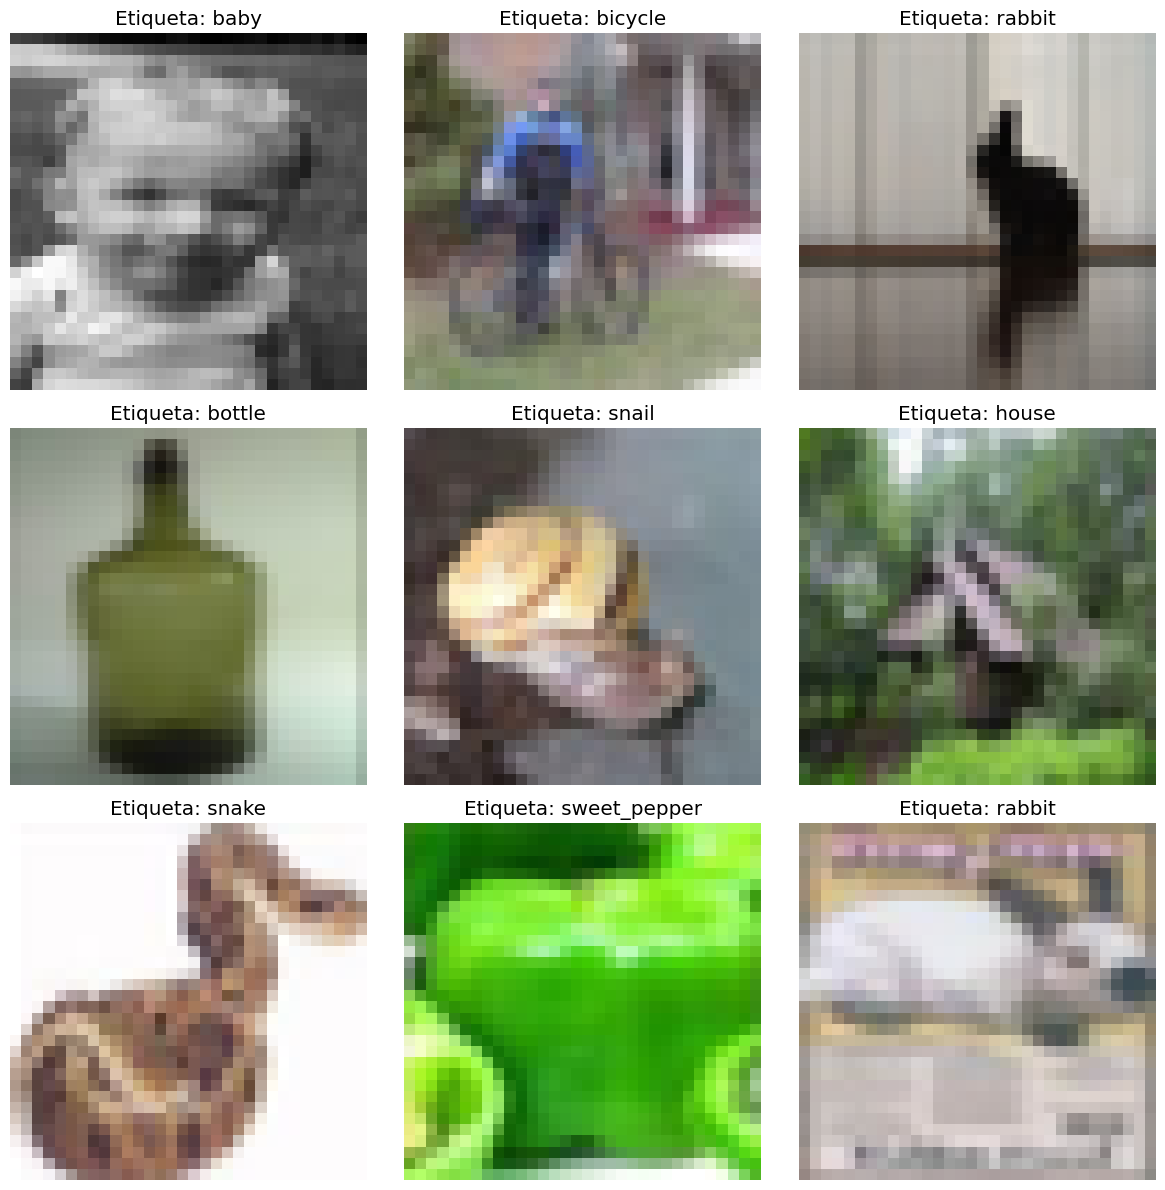

In [34]:
# Selecciona 9 índices aleatorios del conjunto de entrenamiento
indices_aleatorios = np.random.choice(len(x_train), 9, replace=False)

# Configurar la figura para 3x3 imágenes
plt.figure(figsize=(12, 12))

for i, index in enumerate(indices_aleatorios):
    # Obtener la imagen y su etiqueta
    image = x_train[index]
    label_index = y_train[index][0]  # Obtener el índice de la clase
    label_name = labelNames[label_index]  # Obtener el nombre de la clase correspondiente
    
    # Crear una subgráfica (3x3)
    plt.subplot(3, 3, i+1)  
    plt.imshow(image)
    plt.title(f"Etiqueta: {label_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 2. Preprocesamiento de imagenes

- Normalizamos imagenes dividiendo entre el valor máximo para tener matrices entre 0 y 1.
- Convertimos las etiquetas en one-hot encoding

In [35]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 100)
y_test = tf.keras.utils.to_categorical(y_test, 100)

In [36]:
print(y_train.shape)

(50000, 100)


Crear partición de validación

In [37]:
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)
print(f"Training data shape x_tr: {x_tr.shape}")

Training data shape x_tr: (40000, 32, 32, 3)


In [38]:
print(f"Training data shape x_tr: {y_tr.shape}")

Training data shape x_tr: (40000, 100)


In [39]:
print(f"Training data shape x_tr: {y_val.shape}")

Training data shape x_tr: (10000, 100)


# 3. Estrategia 1: Transfer Learning con modelos preentrenados

## 3.1. Arquitectura del modelo

## 3.2. Compilación del modelo

## 3.3. Entrenamiento del modelo

## 3.4. Validación del modelo

# 4. Estrategia 2: Modelo desde cero

## 4.1. Arquitectura del modelo

Definimos un MLP sequential con un tensor de entrada de 32x32 y RGB, que se convierte en un vector unidimensional de 3072 valores.

In [40]:
model_base0 = Sequential([
    # Input Layer
    Input(shape=(x_tr.shape[1], x_tr.shape[2], x_tr.shape[3])),

    # Convolutional Block 1
    Conv2D(32, (3, 3), padding="same", activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding="same", activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.1),

    # Convolutional Block 2
    Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Convolutional Block 3
    Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Convolutional Block 4
    Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Conv2D(256, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),


    # Top Model
    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(512, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

Se usa input para optimizar el código y se añade el kernel_regularizer l2 para reducir overfiting

In [41]:
model_base0.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,018,948 (7.70 MB)

 Trainable params: 2,014,980 (7.69 MB)

 Non-trainable params: 3,968 (15.50 KB)

## 4.2. Compilamos el modelo

In [42]:
model_base0.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [43]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=15),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', 
                                        factor=0.2,
                                        patience=5,
                                        min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint('best_model.h5', 
                                     save_best_only=True)
]

## 4.3. Entrenamiento del modelo

In [44]:
print("[INFO]: Training the model...")
H = model_base0.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

[INFO]: Training the model...


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.0354 - loss: 5.3483 - val_accuracy: 0.0210 - val_loss: 5.6838
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.1004 - loss: 4.1976 - val_accuracy: 0.1338 - val_loss: 3.8734
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.1613 - loss: 3.7470 - val_accuracy: 0.1998 - val_loss: 3.5380
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.2082 - loss: 3.4490 - val_accuracy: 0.2680 - val_loss: 3.1713
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.2591 - loss: 3.1679 - val_accuracy: 0.3128 - val_loss: 2.8978
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.3045 - loss: 2.9367 - val_accuracy: 0.3261 - val_loss: 2.8800
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.3366 - loss: 2.7765 - val_accuracy: 0.3819 - val_loss: 2.6045
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.3740 - loss: 2.6122 - 

### 4.4. Muestreo de gráfica

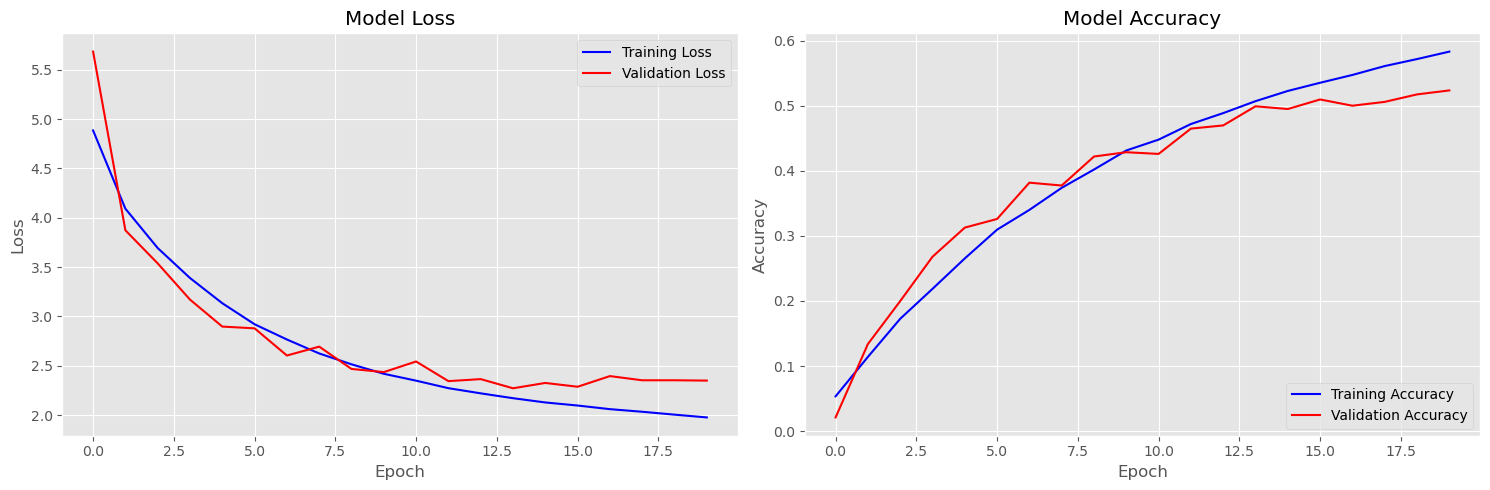

In [45]:
# Get number of epochs from history
n_epochs = len(H.history["loss"])

# Create figure with two subplots
plt.style.use("ggplot")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
ax1.plot(np.arange(0, n_epochs), H.history["loss"], label="Training Loss", color='blue')
ax1.plot(np.arange(0, n_epochs), H.history["val_loss"], label="Validation Loss", color='red')
ax1.set_title("Model Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(loc='upper right')

# Plot Accuracy
ax2.plot(np.arange(0, n_epochs), H.history["accuracy"], label="Training Accuracy", color='blue')
ax2.plot(np.arange(0, n_epochs), H.history["val_accuracy"], label="Validation Accuracy", color='red')
ax2.set_title("Model Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend(loc='lower right')

# Adjust layout and display
plt.tight_layout()
plt.show()

## 4.4. Validación del modelo

Devolvemos la predicción a la clase correspondiente, para comprobar su eficacia

In [46]:
print(classification_report(y_test.argmax(axis=1), model_base0.predict(x_test).argmax(axis=1), target_names=labelNames))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
               precision    recall  f1-score   support

        apple       0.78      0.75      0.77       100
aquarium_fish       0.55      0.63      0.59       100
         baby       0.33      0.30      0.31       100
         bear       0.31      0.09      0.14       100
       beaver       0.20      0.26      0.23       100
          bed       0.45      0.48      0.46       100
          bee       0.54      0.68      0.60       100
       beetle       0.61      0.52      0.56       100
      bicycle       0.66      0.73      0.70       100
       bottle       0.69      0.70      0.70       100
         bowl       0.53      0.28      0.37       100
          boy       0.24      0.33      0.28       100
       bridge       0.70      0.45      0.55       100
          bus       0.61      0.31      0.41       100
    butterfly       0.39      0.58      0.47       100
        camel       0.41      0.48      0.44       100
          can       0.6

# 5. Comparación de modelos